In [5]:
!pip install facenet-pytorch torch torchvision matplotlib pillow requests

obama1.jpg is corrupted or invalid. Deleting to re-download...
obama2.jpg is corrupted or invalid. Deleting to re-download...
Images downloaded successfully!

--- Obama Image 1 ---


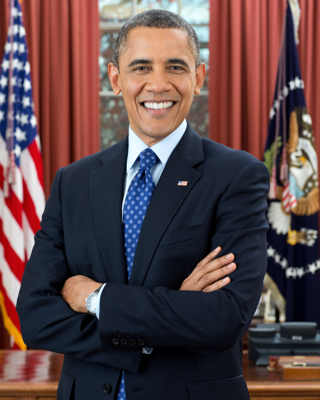


--- Obama Image 2 ---


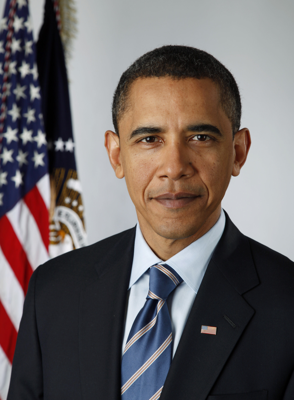

In [7]:
import os
import requests
from PIL import Image
from IPython.display import display

def download_image(url, filename):
    # Check if file exists and is a valid image. If not, delete and re-download.
    if os.path.exists(filename):
        try:
            with Image.open(filename) as img:
                img.verify()
        except Exception:
            print(f"{filename} is corrupted or invalid. Deleting to re-download...")
            os.remove(filename)

    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        }
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
        else:
            print(f"Failed to download. Status code: {response.status_code}")
    else:
        print(f"{filename} already exists and is valid.")

# Download two images of Barack Obama
obama1_url = "https://upload.wikimedia.org/wikipedia/commons/8/8d/President_Barack_Obama.jpg"
obama2_url = "https://upload.wikimedia.org/wikipedia/commons/e/e9/Official_portrait_of_Barack_Obama.jpg"

download_image(obama1_url, "obama1.jpg")
download_image(obama2_url, "obama2.jpg")

print("Images downloaded successfully!")

# Display the downloaded images
print("\n--- Obama Image 1 ---")
img1 = Image.open("obama1.jpg")
img1.thumbnail((400, 400))
display(img1)

print("\n--- Obama Image 2 ---")
img2 = Image.open("obama2.jpg")
img2.thumbnail((400, 400))
display(img2)

In [8]:
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Set device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

# Initialize MTCNN for face detection
# keep_all=False ensures we only take the most prominent face
mtcnn = MTCNN(image_size=160, margin=20, keep_all=False, device=device, post_process=True)

# Initialize FaceNet (InceptionResnetV1) for face recognition
facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print("Models loaded successfully!")

Running on device: cuda
Models loaded successfully!


Face detected with 100.00% confidence.


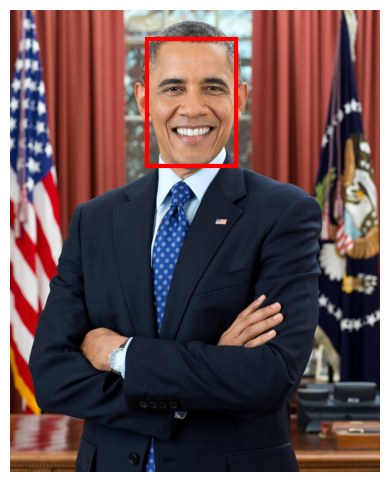

In [9]:
def detect_and_display(image_path):
    img = Image.open(image_path).convert('RGB')

    # Detect face
    boxes, probs = mtcnn.detect(img)

    if boxes is not None:
        box = boxes[0]
        prob = probs[0]
        print(f"Face detected with {prob:.2%} confidence.")

        # Draw bounding box
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        ax = plt.gca()
        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], fill=False, color='red', linewidth=3)
        ax.add_patch(rect)
        plt.axis('off')
        plt.show()
    else:
        print("No face detected!")

detect_and_display("obama1.jpg")

In [10]:
def get_embedding(image_path):
    img = Image.open(image_path).convert('RGB')

    # Get cropped and aligned face tensor
    face_tensor = mtcnn(img)

    if face_tensor is not None:
        # Add batch dimension and move to device
        face_tensor = face_tensor.unsqueeze(0).to(device)

        # Get embedding (vector of 512 dimensions)
        with torch.no_grad():
            embedding = facenet(face_tensor)

        return embedding.squeeze(0).cpu().numpy()
    return None

# Extract embeddings for both images
emb1 = get_embedding("obama1.jpg")
emb2 = get_embedding("obama2.jpg")

if emb1 is not None and emb2 is not None:
    print(f"Embedding shape: {emb1.shape} (512-dimensional vector)")

    # Calculate Cosine Similarity
    cos_sim = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    print(f"\nCosine Similarity between the two images: {cos_sim:.4f}")

    # A threshold of 0.6 is common for vggface2
    threshold = 0.6
    if cos_sim >= threshold:
        print("\n✅ CONCLUSION: MATCH! These are the same person.")
    else:
        print("\n❌ CONCLUSION: NO MATCH! These are different people.")

Embedding shape: (512,) (512-dimensional vector)

Cosine Similarity between the two images: 0.8537

✅ CONCLUSION: MATCH! These are the same person.
